### Adaptive RAG

In [72]:
import os
from dotenv import load_dotenv
load_dotenv() ## aloading all the environment variable


os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [73]:
### Build Index

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

### from langchain_cohere import CohereEmbeddings

# Set embeddings
embd = OpenAIEmbeddings()

# Docs to index
urls = [
    "https://www.technia.com/en/user-experience/software/value-components/"
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)


retriever=vectorstore.as_retriever()

In [74]:
from langchain.tools.retriever import create_retriever_tool
retriever_technia_website=create_retriever_tool(
    retriever,
    "retriever_technia_website",
    "Search and run information about Value Components marketing material"
)

In [75]:
embd = OpenAIEmbeddings()

# Docs to index
urls = [
    "https://products.technia.com/app/docs/tvc-helium-documentation-2025.3.0/helium/admin/index.html"
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)


retriever=vectorstore.as_retriever()

In [76]:
from langchain.tools.retriever import create_retriever_tool
retriever_helium_docs=create_retriever_tool(
    retriever,
    "retriever_helium_docs",
    "Search and run information about Helium detailed documentation like concepts and configuration"
)

In [ ]:
CONFLUENCE_API_KEY=os.getenv("CONFLUENCE_API_KEY")
CONFLUENCE_EMAIL=os.getenv("CONFLUENCE_EMAIL")
CONFLUENCE_SPACE=os.getenv("CONFLUENCE_SPACE")
CONFLUENCE_URL = os.getenv("CONFLUENCE_URL")

from langchain_community.document_loaders import ConfluenceLoader
loader = ConfluenceLoader(
    url=CONFLUENCE_URL,
    username=CONFLUENCE_EMAIL,
    api_key=CONFLUENCE_API_KEY,
    space_key=CONFLUENCE_SPACE,
    include_attachments=False,
    limit=50,
)
documents = loader.load()

In [78]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(documents)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)


retriever=vectorstore.as_retriever()

In [79]:
documents[0].metadata['title']

'2015.1 / Helium meeting PoC'

In [80]:
titleList=[]

In [81]:
for doc in documents:
    titleList.append(doc.metadata['title'])

In [82]:
titleList

['2015.1 / Helium meeting PoC',
 'Technical improvements',
 'SASS',
 'Routing and resource handling',
 'Libraries and techniques',
 'Responsibility Areas',
 'Sprint Planning',
 'Helium Home',
 'Page Request Strategy',
 'How should data be shared between widgets?',
 'Charts',
 'Data Format',
 'Decisions',
 'Collaboration',
 'Helium Q&A / FAQ',
 'Helium planning 2016',
 'Documentation Structure',
 'Helium - troubleshooting and Error FAQ',
 'USBA prioritized requirements',
 'Mobile initiative',
 'NSX Standalone usage - WIP',
 'HE standalone - Decoupling ideas',
 'ARCHIVE USBA prioritized requirements',
 'HE Training ToC draft',
 'Archive',
 'FAQ',
 'Webpack and ES6 Modules',
 'Technical',
 'Sharing Object Data in App',
 'Offline - strategy',
 'Working plan',
 'PLMIF 2019',
 'Config and impl work TBD',
 'Demo script',
 'PPT links and content',
 'Config and impl work DONE',
 'NSX update & roadmap',
 'Archive UI for legacy Enovia DB - MHC',
 'Grid Implementation',
 'Feature Mapping',
 '2025.

In [83]:
", ".join(titleList)

'2015.1 / Helium meeting PoC, Technical improvements, SASS, Routing and resource handling, Libraries and techniques, Responsibility Areas, Sprint Planning, Helium Home, Page Request Strategy, How should data be shared between widgets?, Charts, Data Format, Decisions, Collaboration, Helium Q&A / FAQ, Helium planning 2016, Documentation Structure, Helium - troubleshooting and Error FAQ, USBA prioritized requirements, Mobile initiative, NSX Standalone usage - WIP, HE standalone - Decoupling ideas, ARCHIVE USBA prioritized requirements, HE Training ToC draft, Archive, FAQ, Webpack and ES6 Modules, Technical, Sharing Object Data in App, Offline - strategy, Working plan, PLMIF 2019, Config and impl work TBD, Demo script, PPT links and content, Config and impl work DONE, NSX update & roadmap, Archive UI for legacy Enovia DB - MHC, Grid Implementation, Feature Mapping, 2025.3, 2025.3.1'

In [84]:
from langchain.tools.retriever import create_retriever_tool
retriever_helium_confluence=create_retriever_tool(
    retriever,
    "retriever_helium_confluence",
    "Search and run information about Helium information for following titles: " + ", ".join(titleList)
)

In [107]:
tools=[retriever_technia_website,retriever_helium_docs, retriever_helium_confluence,web_search_tool]

In [108]:
from langchain_openai import ChatOpenAI
from langchain.agents import initialize_agent, AgentType

llm = ChatOpenAI(model="gpt-4o-mini")


agent = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.OPENAI_FUNCTIONS,
    verbose=True,
)

response = agent.invoke({"input": "when is next cricket world cup?"})
print(response['output'])



> Entering new AgentExecutor chain...

Invoking: `tavily_search_results_json` with `{'query': 'next cricket world cup schedule'}`


[{'title': 'Next ICC Tournaments 2025-2031: Schedule, Host Countries and ...', 'url': 'https://www.jagranjosh.com/general-knowledge/upcoming-icc-tournaments-host-country-year-wise-1719992888-1', 'content': "The highly anticipated tournament, hosted by Pakistan, is scheduled to take place from February 19 to March 9, promising an action-packed three weeks of top-tier cricket. Here is the complete list: [...] Additionally, the ICC World Test Championship Finals are scheduled for 2025, 2027, 2029, and 2031, highlighting the pinnacle of Test cricket. These tournaments aim to enhance global engagement and showcase the sport's diversity and competitiveness.\n\nALSO READ| List Of T20 World Cup Winners Till 2024\n\n## Next ICC Tournaments from 2025 to 2031\n\nFollowing the thrilling Women's T20 World Cup, the men's team will return to the international stage in 

In [109]:
from rich.console import Console
from rich.markdown import Markdown
console = Console()
md = Markdown(response['output'])   # response.content contains markdown text
console.print(md)

The next Cricket World Cup is the ICC Men's Cricket World Cup 2023, which is being hosted by India. It is scheduled
to run from October 5 to November 19, 2023.                                                                        

Following that, the next Men's Cricket World Cup will be in 2027, scheduled to be played in South Africa, Zimbabwe,
and Namibia in October and November 2027.

In [89]:
Document(response['output'])

Document(metadata={}, page_content='The New Search Experience allows users to leverage a more integrated search functionality within the Helium or Enovia system. It supports access to federated search results through a dedicated API and enhances user experience by enabling features such as customizable result displays and integration with various data sources.\n\n### Configuration Steps for New Search Experience\n\nTo configure the New Search Experience, follow these guidelines:\n\n1. **Search Configuration**:\n   You must explicitly set the `externalSearchURL` to true in your search configuration. The sample XML configuration is as follows:\n\n   ```xml\n   <Search provider="enovia">\n       <Limit>120</Limit>\n       <SearchOnCriteriaUpdate>true</SearchOnCriteriaUpdate>\n       <SearchOnLoad>false</SearchOnLoad>\n       <OpenOnLoad>true</OpenOnLoad>\n       <SearchForm ref="tvc:searchformv2:helium/TopBarSearchForm.xml" />\n       <Settings>\n           <Setting name="externalSearchUR

In [90]:
### Router

from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

# Data model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )

# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# Prompt
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | structured_llm_router

print(
    question_router.invoke(
        {"question": "Who won the Cricket world cup 2023 "}
    )
)


datasource='web_search'


In [91]:
print(question_router.invoke({"question": "What are the types of agent memory?"}))

datasource='vectorstore'


In [92]:
### Retrieval Grader


# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
## context
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='no'


In [93]:
### Generate

from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull("rlm/rag-prompt")

# LLM
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

I don't know.


In [94]:
### Hallucination Grader


# Data model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(binary_score='no')

In [95]:
### Answer Grader


# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM with function call
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='no')

In [96]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'What are the key concepts and functionalities of agent memory in artificial intelligence?'

In [97]:
### Search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

In [98]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [99]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="qwen/qwen3-32b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [100]:
from langchain.schema import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever_helium_docs.invoke(question)
    documents.append(retriever_helium_confluence.invoke(question))
    documents.append(retriever_technia_website.invoke(question))
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)

    return {"documents": web_results, "question": question}


### Edges ###


def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question})
    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

In [101]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()

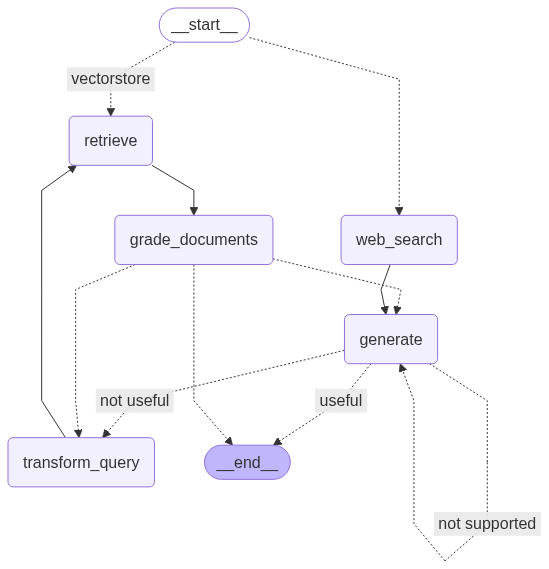

In [102]:
from IPython.display import Image, display

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [105]:
app.invoke({"question":"What is Helium"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is Helium',
 'generation': 'Helium is a colorless, odorless, and tasteless inert gas with the chemical symbol He and atomic number 2. It is the second most abundant element in the universe, primarily found in stars, and has the lowest boiling point of any element. Helium is used in various applications, including as a lifting gas for balloons and as a coolant in cryogenics.',
 'documents': Document(metadata={}, page_content="Helium (from Greek: ἥλιος, romanized: helios, lit.\u2009'sun') is a chemical element; it has symbol He and atomic number 2. It is a colorless, odorless, non-toxic, inert, monatomic gas and the first in the noble gas group in the periodic table. Its boiling point is the lowest among all the elements, and it does not have a melting point at standard pressures. It is the second-lightest and second-most abundant element in the observable universe, after hydrogen. It is present at about 24% of the total [...] Helium is the second least reactive noble 

In [104]:
app.invoke({"question":"What is agent memory"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---


AttributeError: 'str' object has no attribute 'append'

In [ ]:
print(CONFLUENCE_API_KEY, CONFLUENCE_EMAIL, CONFLUENCE_SPACE)

ATATT3xFfGF00HojrRWZ-aagcErr9nwCMXL3aFVETtSfKsk36kPslAzfVXLp-Wi2l7q4pNmROfACLUfa8qP3nTyY40APHo57G7gOU0xDFxvXKD69cpIreJdek2qvXGUSKEqA6m863jeJVLCA-gmnYcXXiK1tfZpmBMNMyd-xx4EihABVc4ACag8=80904017 ashishpal.singh@technia.com Helium


In [ ]:
documents

[Document(metadata={'title': '2015.1 / Helium meeting PoC', 'id': '117211336', 'source': 'https://technia.jira.com/wiki/spaces/HE/pages/117211336/2015.1+Helium+meeting+PoC', 'when': '2015-09-16T13:36:10.876Z'}, page_content='Highlevel goal with 2015.1 TIF tbd LightWeithg Alfa Offline create 2015x support Demo av Peters offline PoC -Agreed to try to include in TVC 2015.1 Define Goal for LightWeight PoC (2015.1 och 2015.2 high level content) Goal develop new modern TVC App and learn things that will be reused What is lightweight Light users (helium) Can be run stand alone Can be used within ENOVIA Set up separate project in jira, run scrum Plannera PoC, technology, use-cases, packaging, etc.. Tollgates & Uppdelning av tasks -Sprint demo 16th of January Get to it..'),
 Document(metadata={'title': 'Technical improvements', 'id': '117211368', 'source': 'https://technia.jira.com/wiki/spaces/HE/pages/117211368/Technical+improvements', 'when': '2018-10-31T21:50:13.392Z'}, page_content='Use SAS

In [ ]:
documents[0].page_content


'Highlevel goal with 2015.1 TIF tbd LightWeithg Alfa Offline create 2015x support Demo av Peters offline PoC -Agreed to try to include in TVC 2015.1 Define Goal for LightWeight PoC (2015.1 och 2015.2 high level content) Goal develop new modern TVC App and learn things that will be reused What is lightweight Light users (helium) Can be run stand alone Can be used within ENOVIA Set up separate project in jira, run scrum Plannera PoC, technology, use-cases, packaging, etc.. Tollgates & Uppdelning av tasks -Sprint demo 16th of January Get to it..'